# 2023 Global Prosperity Index Analysis - David Custer

## Table of Contents:
* [First Bullet Header](#first-bullet)
* [Second Bullet Header](#second-bullet)

## Packages

In [4]:
%pip install --quiet matplotlib notebook numpy pandas plotly scikit-learn seaborn

Note: you may need to restart the kernel to use updated packages.


## First Bullet Header <a class="anchor" id="first-bullet"></a>

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import plotly.express as px

## Data Wrangling

In [5]:
prosperity_ranks = pd.read_csv(r"C:\Users\anon\Python Files\STAT 531\2023globalpropserity.csv")
display(prosperity_ranks) # We want to extract the relevant political regimes and regions.

,country,code,region,political_regime,prosperity_rank,safety_and_security,personal_freedom,governance,social_capital,investment_environment,enterprise_conditions,infrastructure_and_market_access,economic_quality,living_conditions,health,education,natural_environment
0,Denmark,DNK,Europe,Liberal Democracy,6.00,6,2,3,1,8,8,9,7,2,16,5,5
1,Sweden,SWE,Europe,Liberal Democracy,6.83,10,4,7,4,6,15,7,8,3,9,8,1
2,Norway,NOR,Europe,Liberal Democracy,7.25,3,1,2,3,9,14,20,5,4,7,10,9
3,Finland,FIN,Europe,Liberal Democracy,8.00,15,3,1,7,2,12,10,20,7,15,2,2
4,Switzerland,CHE,Europe,Liberal Democracy,6.75,2,12,4,12,12,1,11,2,5,10,4,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154,Somalia,SOM,Africa,Closed Autocracy,153.62,160,141,161,143,153,140,165,165,159,163,158,136
155,Afghanistan,AFG,Asia,Closed Autocracy,154.25,166,148,149,166,154,139,159,152,153,153,157,155
156,Central African Republic,CAF,Africa,Electoral Autocracy,150.38,157,135,155,160,160,149,166,130,167,167,165,93
157,Yemen,YEM,Asia,Closed Autocracy,156.88,165,159,166,157,165,160,156,164,148,136,155,152


In [6]:
pd.set_option("display.max_rows", 10)
prosperity_scores = pd.read_csv(r"C:\Users\anon\Python Files\STAT 531\data.csv")
display(prosperity_scores)

# check for missing values

pd.set_option("display.max_rows", 20)
prosperity_scores.isnull().sum() # no more missing values

,country,region,political_regime,prosperity_score,safety_and_security,personal_freedom,governance,social_capital,investment_environment,enterprise_conditions,infrastructure_and_market_access,economic_quality,living_conditions,health,education,natural_environment
0,Denmark,Europe,Liberal Democracy,84.55,92.59,94.09,89.45,82.56,82.42,79.64,78.79,76.81,95.77,81.07,87.48,73.94
1,Sweden,Europe,Liberal Democracy,83.67,90.97,91.90,86.41,78.29,82.81,75.54,79.67,76.18,95.33,82.28,85.92,78.74
2,Norway,Europe,Liberal Democracy,83.59,93.30,94.10,89.66,79.03,82.24,75.95,75.87,77.25,94.70,82.98,85.68,72.37
3,Finland,Europe,Liberal Democracy,83.47,89.56,91.96,90.41,77.27,84.12,77.25,78.77,70.28,94.46,81.19,88.38,77.99
4,Switzerland,Europe,Liberal Democracy,83.42,95.66,87.50,87.67,69.14,80.81,83.84,78.65,79.71,94.66,82.11,87.72,73.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,Somalia,Africa,Closed Autocracy,34.39,31.91,34.32,23.80,43.50,31.16,41.79,26.75,28.23,32.07,44.38,26.32,48.46
163,Afghanistan,Asia,Closed Autocracy,34.18,20.93,31.02,29.47,31.17,30.25,42.01,29.67,33.75,39.74,50.91,27.11,44.11
164,Central African Republic,Africa,Electoral Autocracy,32.83,35.30,36.83,28.40,36.72,26.32,40.21,25.49,40.34,19.21,31.95,18.62,54.57
165,Yemen,Middle East,Closed Autocracy,32.65,22.60,25.30,18.20,38.44,22.76,33.12,30.93,28.81,41.58,57.45,28.12,44.49


country                             0
region                              0
political_regime                    0
prosperity_score                    0
safety_and_security                 0
personal_freedom                    0
governance                          0
social_capital                      0
investment_environment              0
enterprise_conditions               0
infrastructure_and_market_access    0
economic_quality                    0
living_conditions                   0
health                              0
education                           0
natural_environment                 0
dtype: int64

## Countries in each Region

In [7]:
country_region_df = prosperity_scores[["country", "region"]]
grouped = country_region_df.groupby("region")["country"].apply(list).reset_index()
grouped["country"] = grouped["country"].apply(sorted)
grouped = grouped.sort_values("region")
max_len = max(grouped["country"].apply(len))
data = {region: countries + [""] * (max_len - len(countries)) for region, 
        countries in zip(grouped["region"], grouped["country"])}
regions_df = pd.DataFrame(data)
sorted_regions_df = regions_df.sort_index(axis=1)
pd.set_option("display.max_rows", 60)
pd.set_option("display.width", 1000)
display(sorted_regions_df)

,Africa,Asia,Caribbean,Central America,Europe,Middle East,North America,Oceania,South America
0,Algeria,Afghanistan,Cuba,Belize,Albania,Armenia,Canada,Australia,Argentina
1,Angola,Bangladesh,Dominican Republic,Costa Rica,Austria,Azerbaijan,Mexico,New Zealand,Bolivia
2,Benin,Cambodia,Haiti,El Salvador,Belarus,Bahrain,United States,Papua New Guinea,Brazil
3,Botswana,China,Jamaica,Guatemala,Belgium,Georgia,,,Chile
4,Burkina Faso,Hong Kong,Trinidad and Tobago,Honduras,Bosnia and Herzegovina,Iran,,,Colombia
5,Burundi,India,,Nicaragua,Bulgaria,Iraq,,,Ecuador
6,Cabo Verde,Indonesia,,Panama,Croatia,Israel,,,Guyana
7,Cameroon,Japan,,,Cyprus,Jordan,,,Paraguay
8,Central African Republic,Kazakhstan,,,Czech Republic,Kuwait,,,Peru
9,Chad,Kyrgyzstan,,,Denmark,Lebanon,,,Suriname


## Visualizations

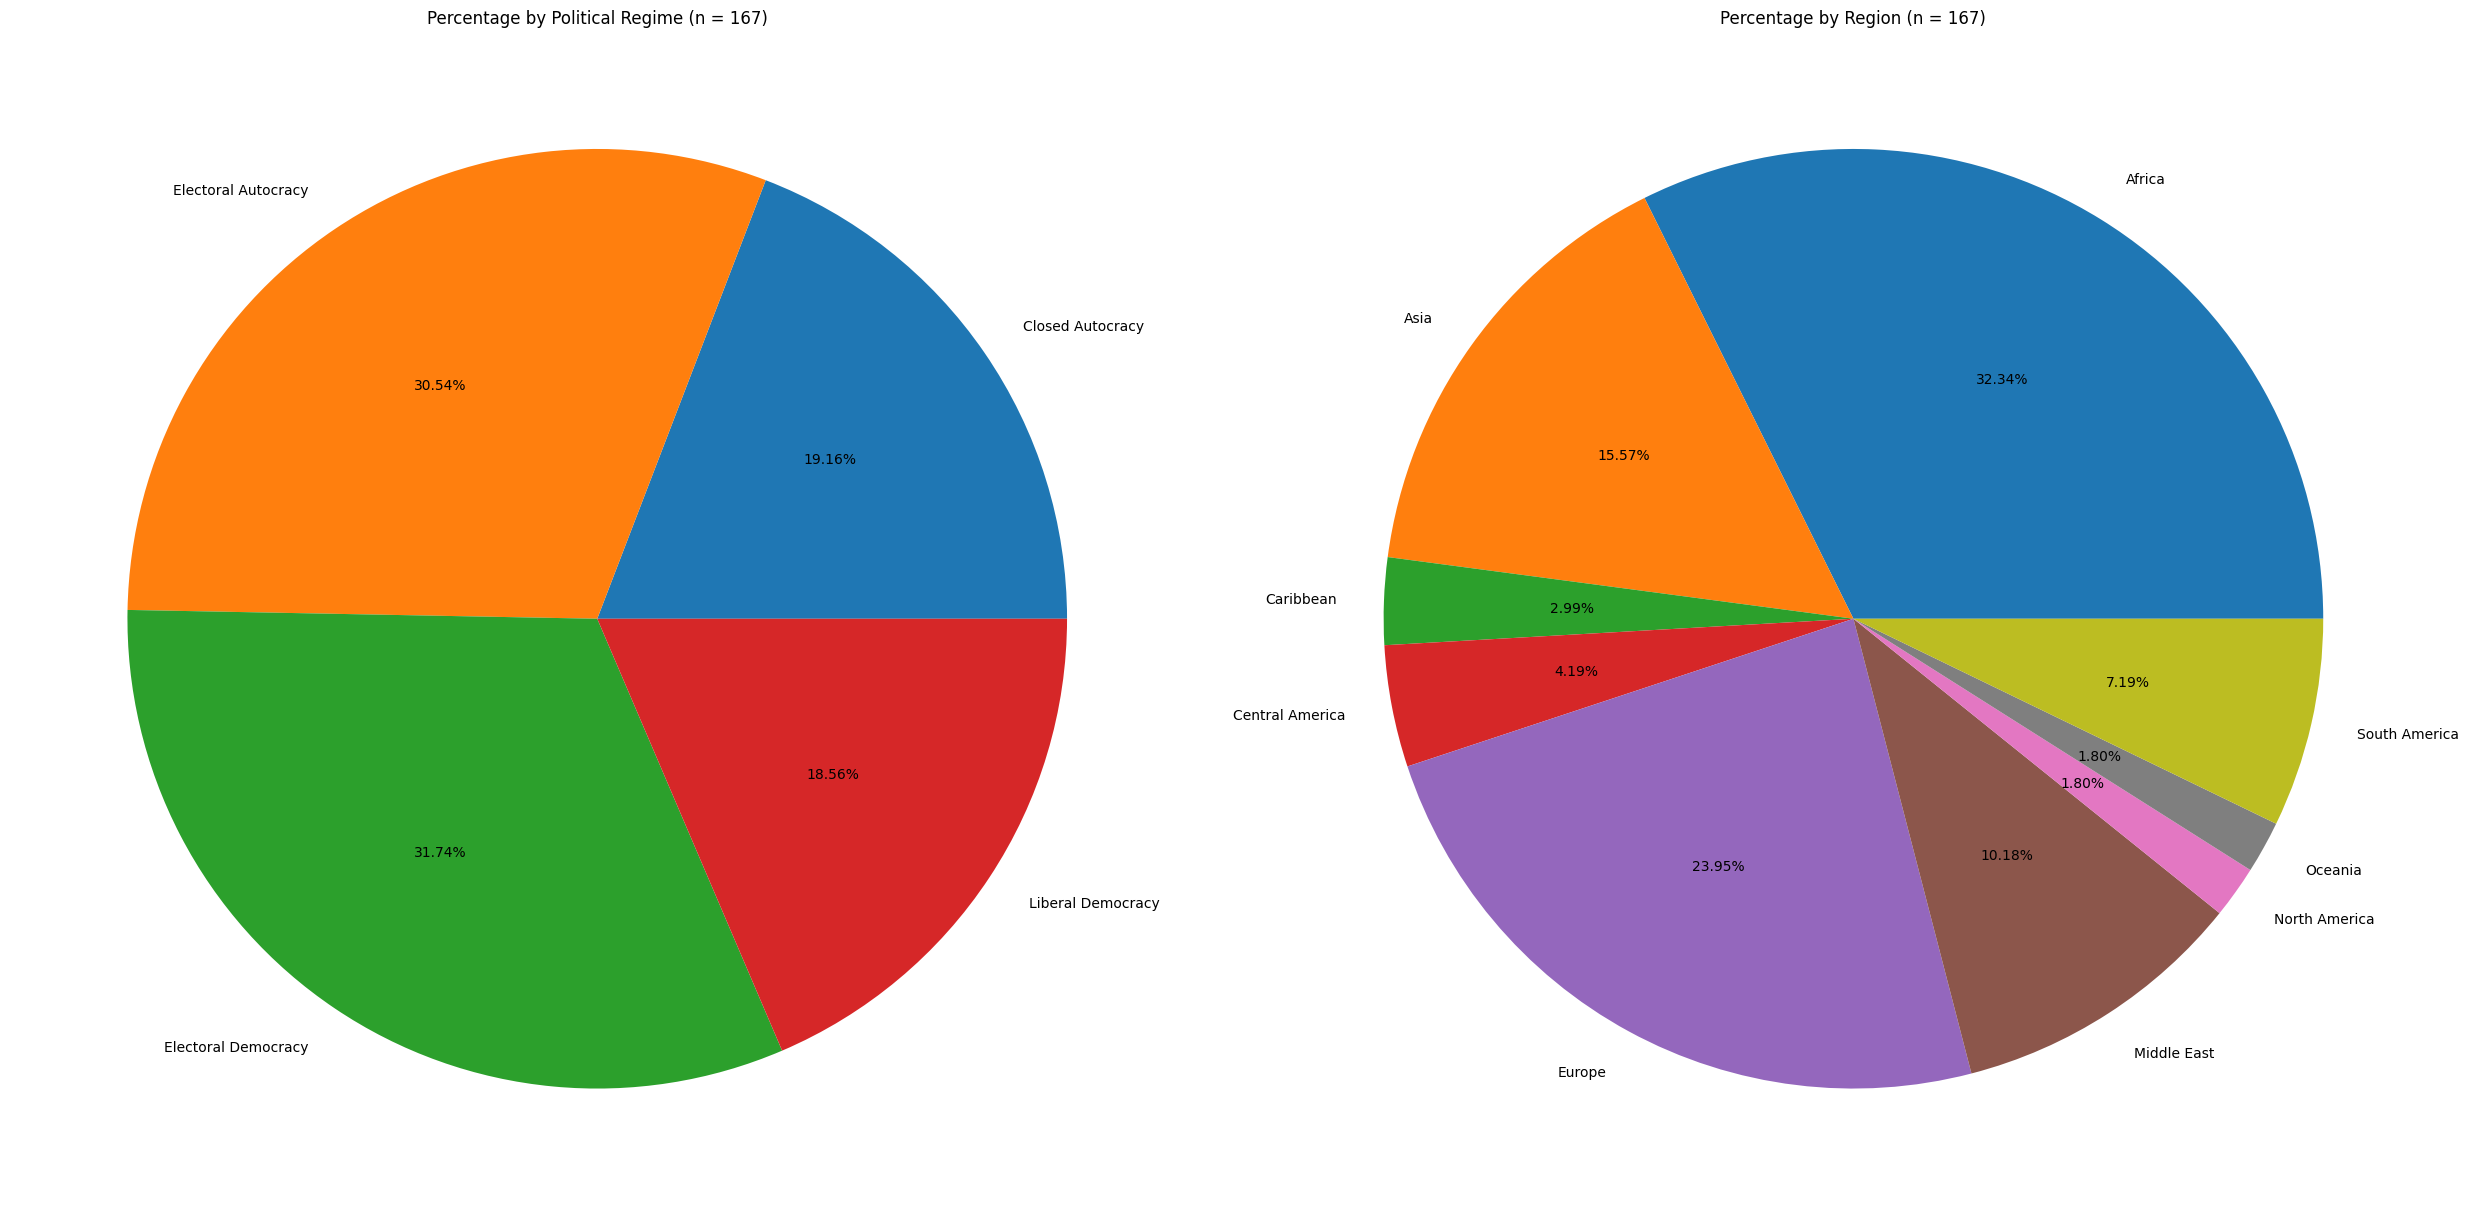

In [13]:
region_coverage = prosperity_scores.groupby("region").size()
political_regime_coverage = prosperity_scores.groupby("political_regime").size()

fig, axes = plt.subplots(1, 2, figsize=(25,20))

political_regime_coverage.plot.pie(autopct = "%.2f%%", ax = axes[0], 
                        title = "Percentage by Political Regime (n = 167)")
region_coverage.plot.pie(autopct = "%.2f%%", ax = axes[1], 
                         title = "Percentage by Region (n = 167)")

plt.tight_layout()
plt.show()

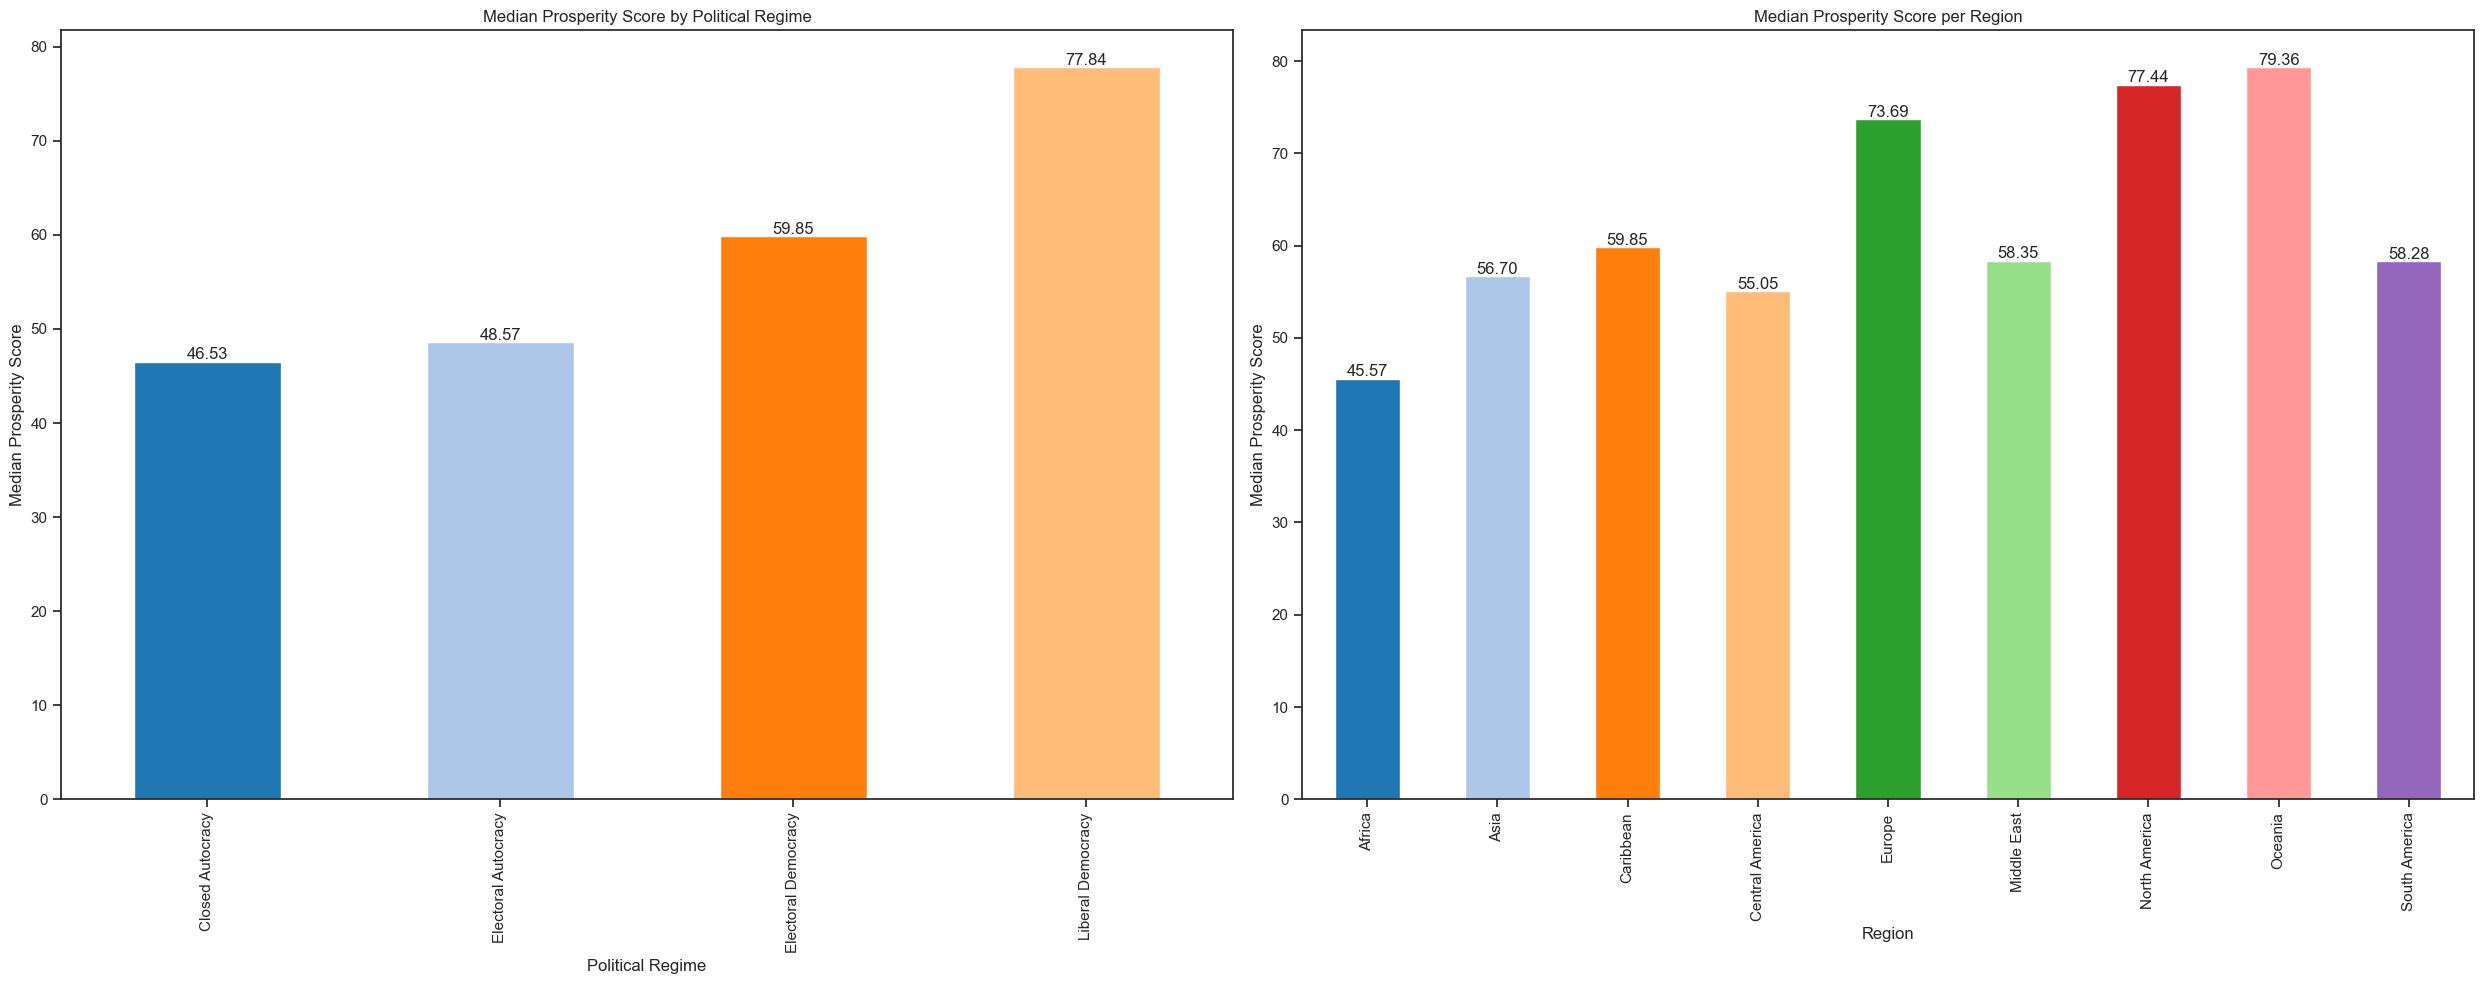

In [96]:
region_median_scores = prosperity_scores.groupby("region")["prosperity_score"].median()
regime_median_scores = prosperity_scores.groupby("political_regime")["prosperity_score"].median()
colors = plt.cm.tab20.colors

fig, axes = plt.subplots(1, 2, figsize=(25, 10))

ax_1 = regime_median_scores.plot(kind="bar", color=colors, ax=axes[0], grid=False,
                                 title="Median Prosperity Score by Political Regime")
ax_1.set_xlabel("Political Regime")
ax_1.set_ylabel("Median Prosperity Score")
for p in ax_1.patches:
    ax_1.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha="center", va="center", xytext=(0, 5), textcoords="offset points")

ax_2 = region_median_scores.plot(kind="bar", color=colors, ax=axes[1], grid=False,
                                 title="Median Prosperity Score per Region")
ax_2.set_xlabel("Region")
ax_2.set_ylabel("Median Prosperity Score")
for p in ax_2.patches:
    ax_2.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha="center", va="center", xytext=(0, 5), textcoords="offset points")

plt.tight_layout()
plt.show()

## Canonical Correlation Analysis

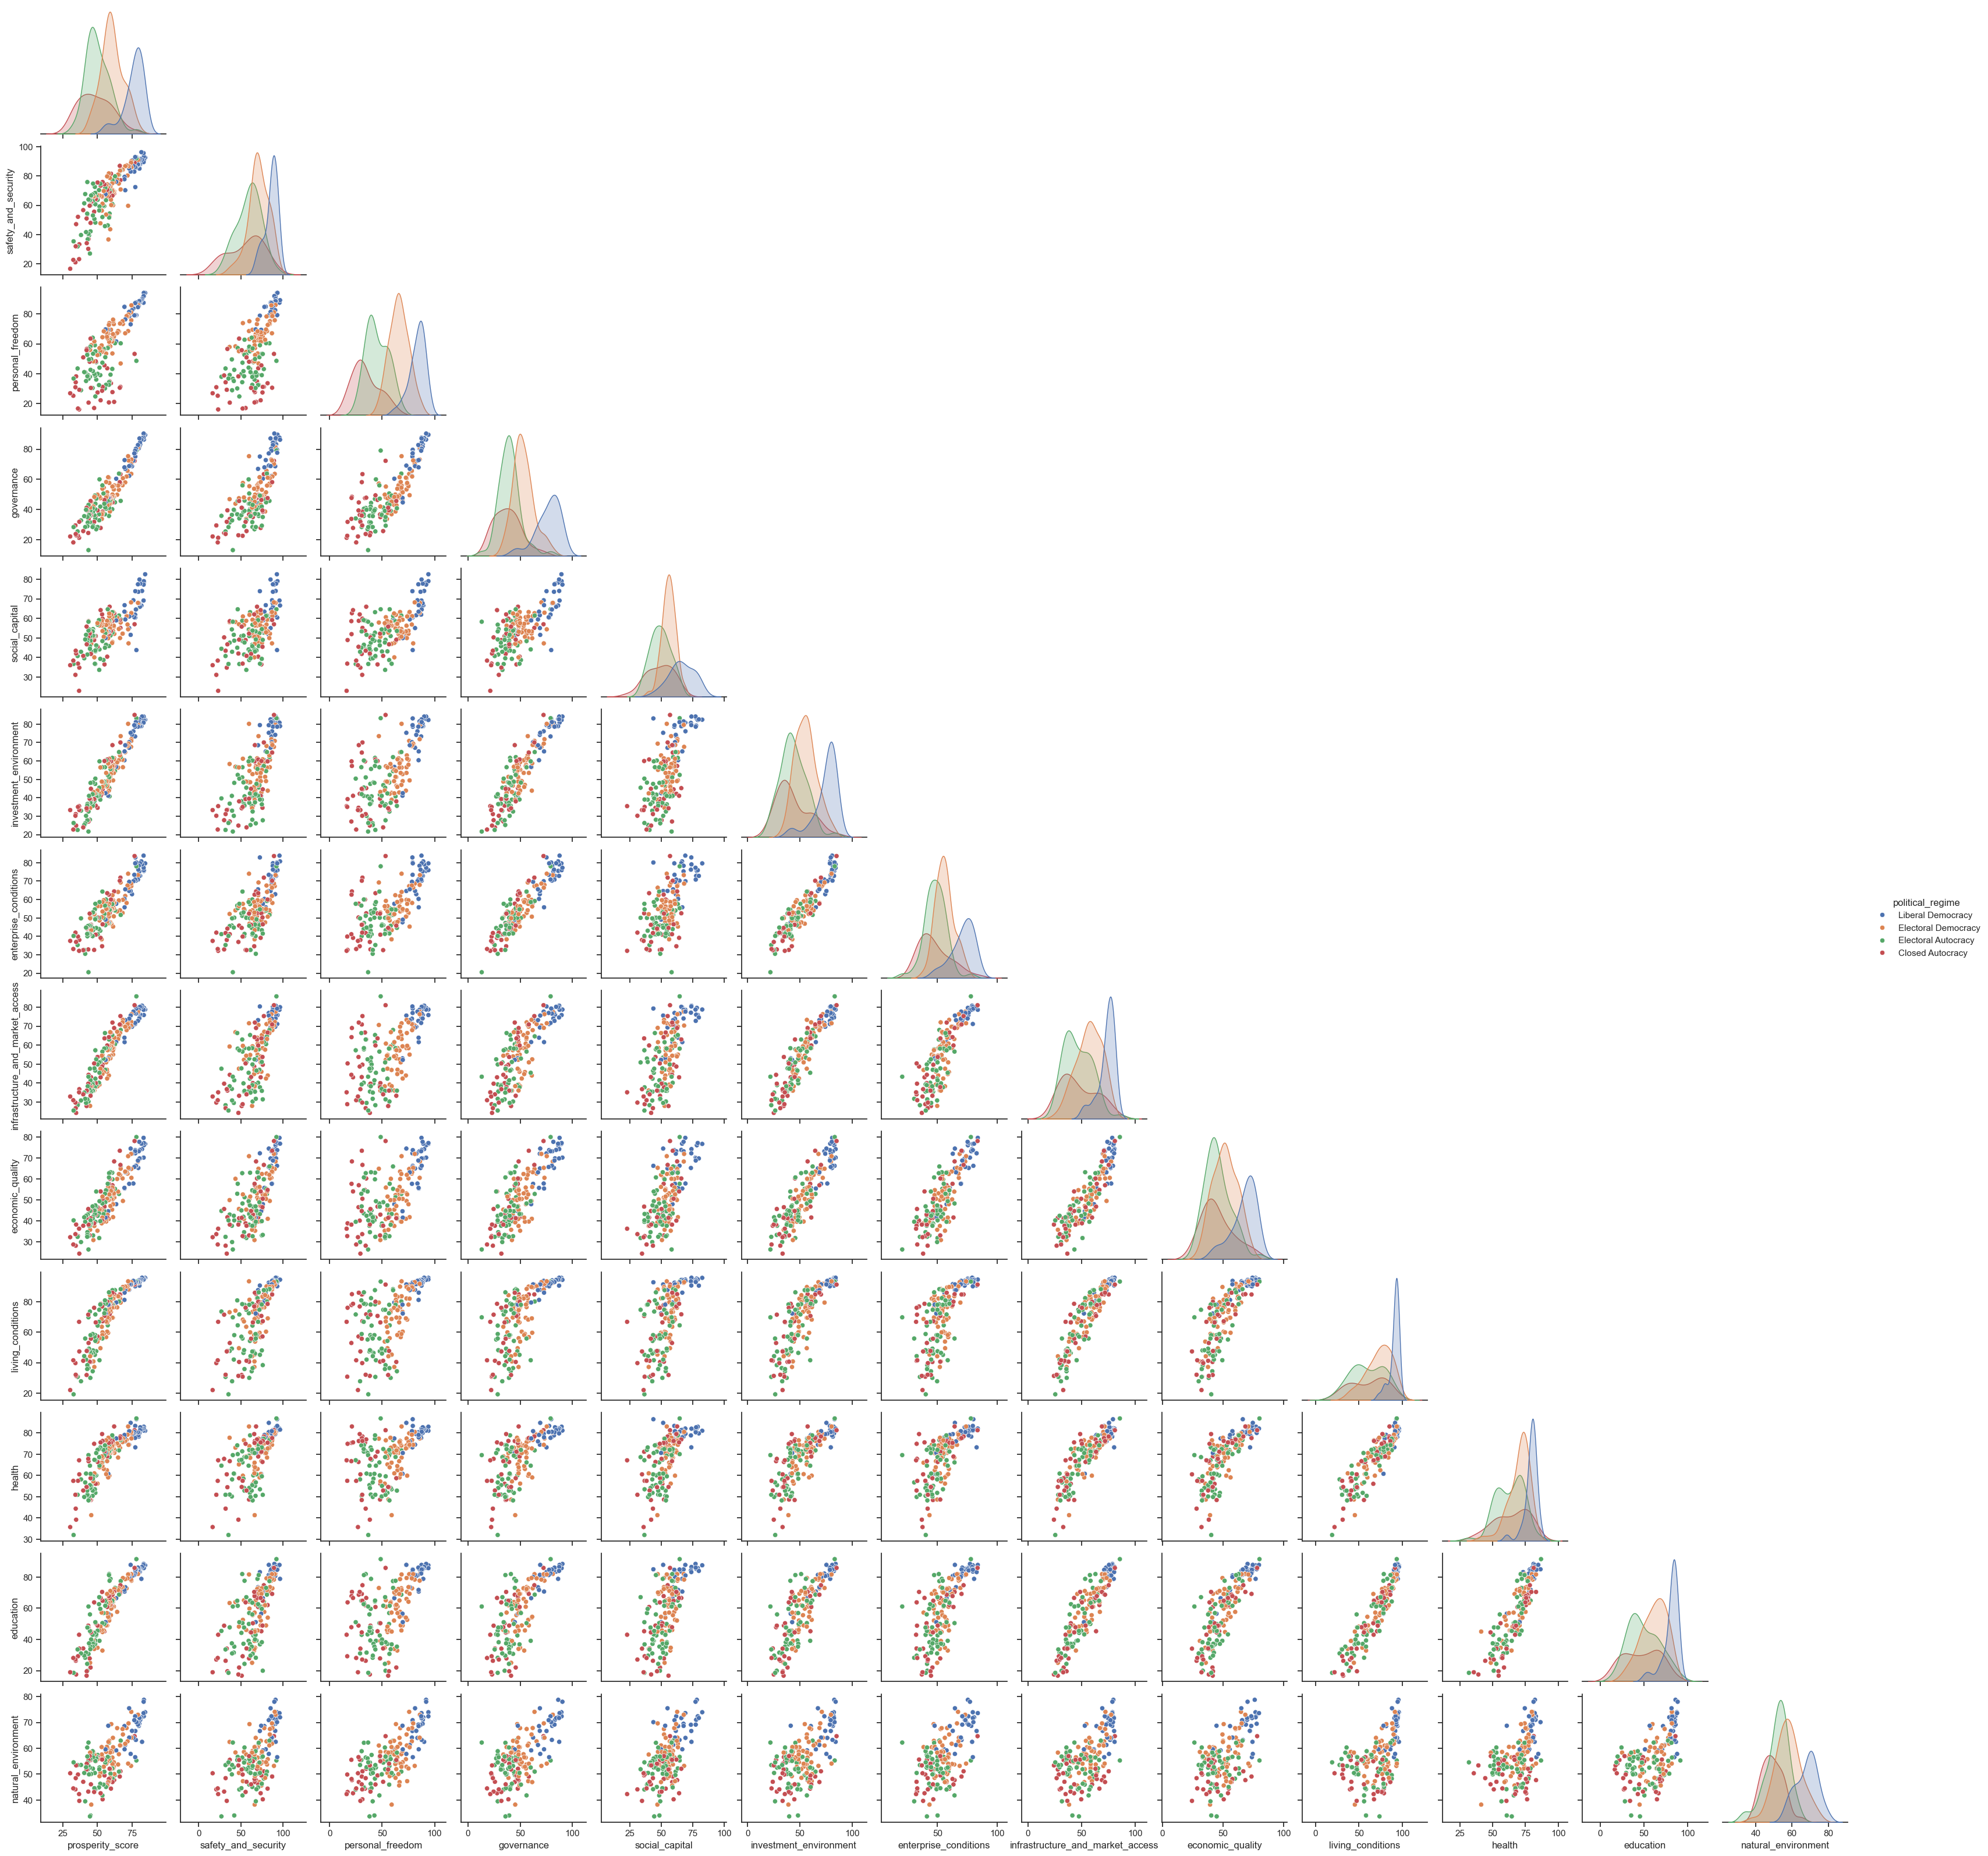

In [ ]:
reduced_scores_cca = prosperity_scores.drop(columns=["country", "region"])
sns.set_theme(style = "ticks")
sns.pairplot(reduced_scores_cca, corner = True, hue = "political_regime");

## Dimensionality Reduction via Principal Components Analysis (PCA)

The continuous variables in the dataset are all scaled out of 100, so, PCA using the covariance instead of the correlation matrix is appropriate.
We need to drop the categorical variables "region" and "political_regime" to continue due to assumptions under PCA. We removed "country" as well.

### Scree Plot

,PC 1,PC 2,PC 3,PC 4,PC 5,PC 6,PC 7,PC 8,PC 9,PC 10
λ,0.780130,0.093019,0.036300,0.031329,0.016727,0.010991,0.008183,0.008083,0.005265,0.004195


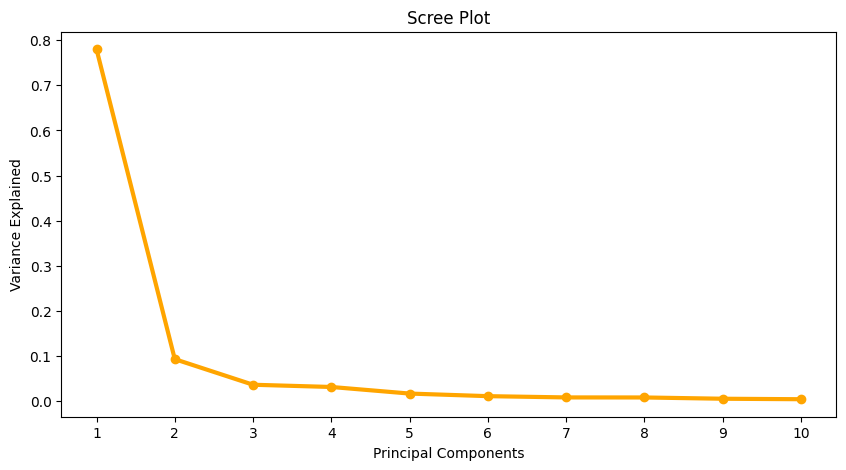

In [14]:
reduced_scores_pca = prosperity_scores.drop(columns=["country", "region", "political_regime"])
pca = PCA(n_components =  10)
pca_fit = pca.fit_transform(reduced_scores_pca)
pd.set_option("display.width", 1000)
lambda_values = pd.DataFrame([pca.explained_variance_ratio_], 
                             columns = ["PC 1", "PC 2", "PC 3", "PC 4", "PC 5", 
                                        "PC 6", "PC 7", "PC 8", "PC 9", "PC 10"], 
                             index = ["λ"])
lambda_values = lambda_values.style.set_properties(**{'text-align': 'right'})
display(lambda_values)
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, pca.n_components_ + 1), pca.explained_variance_ratio_, 
         "o-", linewidth = 3, color = "orange")
plt.title("Scree Plot")
plt.xticks(np.arange(1, 11))
plt.xlabel("Principal Components")
plt.ylabel("Variance Explained")
plt.show()

### PC Loadings

In [61]:
loadings = pd.DataFrame(pca.components_.T, 
                        columns = ["PC 1", "PC 2", "PC 3", "PC 4", "PC 5",
                                   "PC 6", "PC 7", "PC 8", "PC 9", "PC 10"], 
                        index = reduced_scores_pca.columns)

print(loadings.iloc[:, :3])

                                      PC 1      PC 2      PC 3
prosperity_score                  0.267640  0.014474 -0.004466
safety_and_security               0.292239  0.144442  0.478355
personal_freedom                  0.302994  0.685837  0.263122
governance                        0.328828  0.284680 -0.318618
social_capital                    0.155898  0.072770  0.083672
investment_environment            0.320120 -0.016955 -0.395215
enterprise_conditions             0.228390  0.079607 -0.467761
infrastructure_and_market_access  0.302201 -0.199507 -0.148099
economic_quality                  0.244556 -0.095655 -0.228091
living_conditions                 0.359580 -0.385193  0.297108
health                            0.190835 -0.240415  0.086526
education                         0.363649 -0.350195  0.198085
natural_environment               0.122468  0.194498  0.097233


### PC Scores

,PC1,PC2,PC3
0,95.804311,17.474234,-4.606116
1,92.160045,15.459529,-3.433307
2,92.734326,17.900381,-3.154421
3,92.245858,16.806269,-5.227933
4,92.680577,12.037880,-7.616580
...,...,...,...
162,-89.069787,8.164257,-11.428080
163,-87.642435,-1.695833,-19.243438
164,-95.658011,22.045033,-16.923151
165,-94.801437,-10.999466,-6.335406


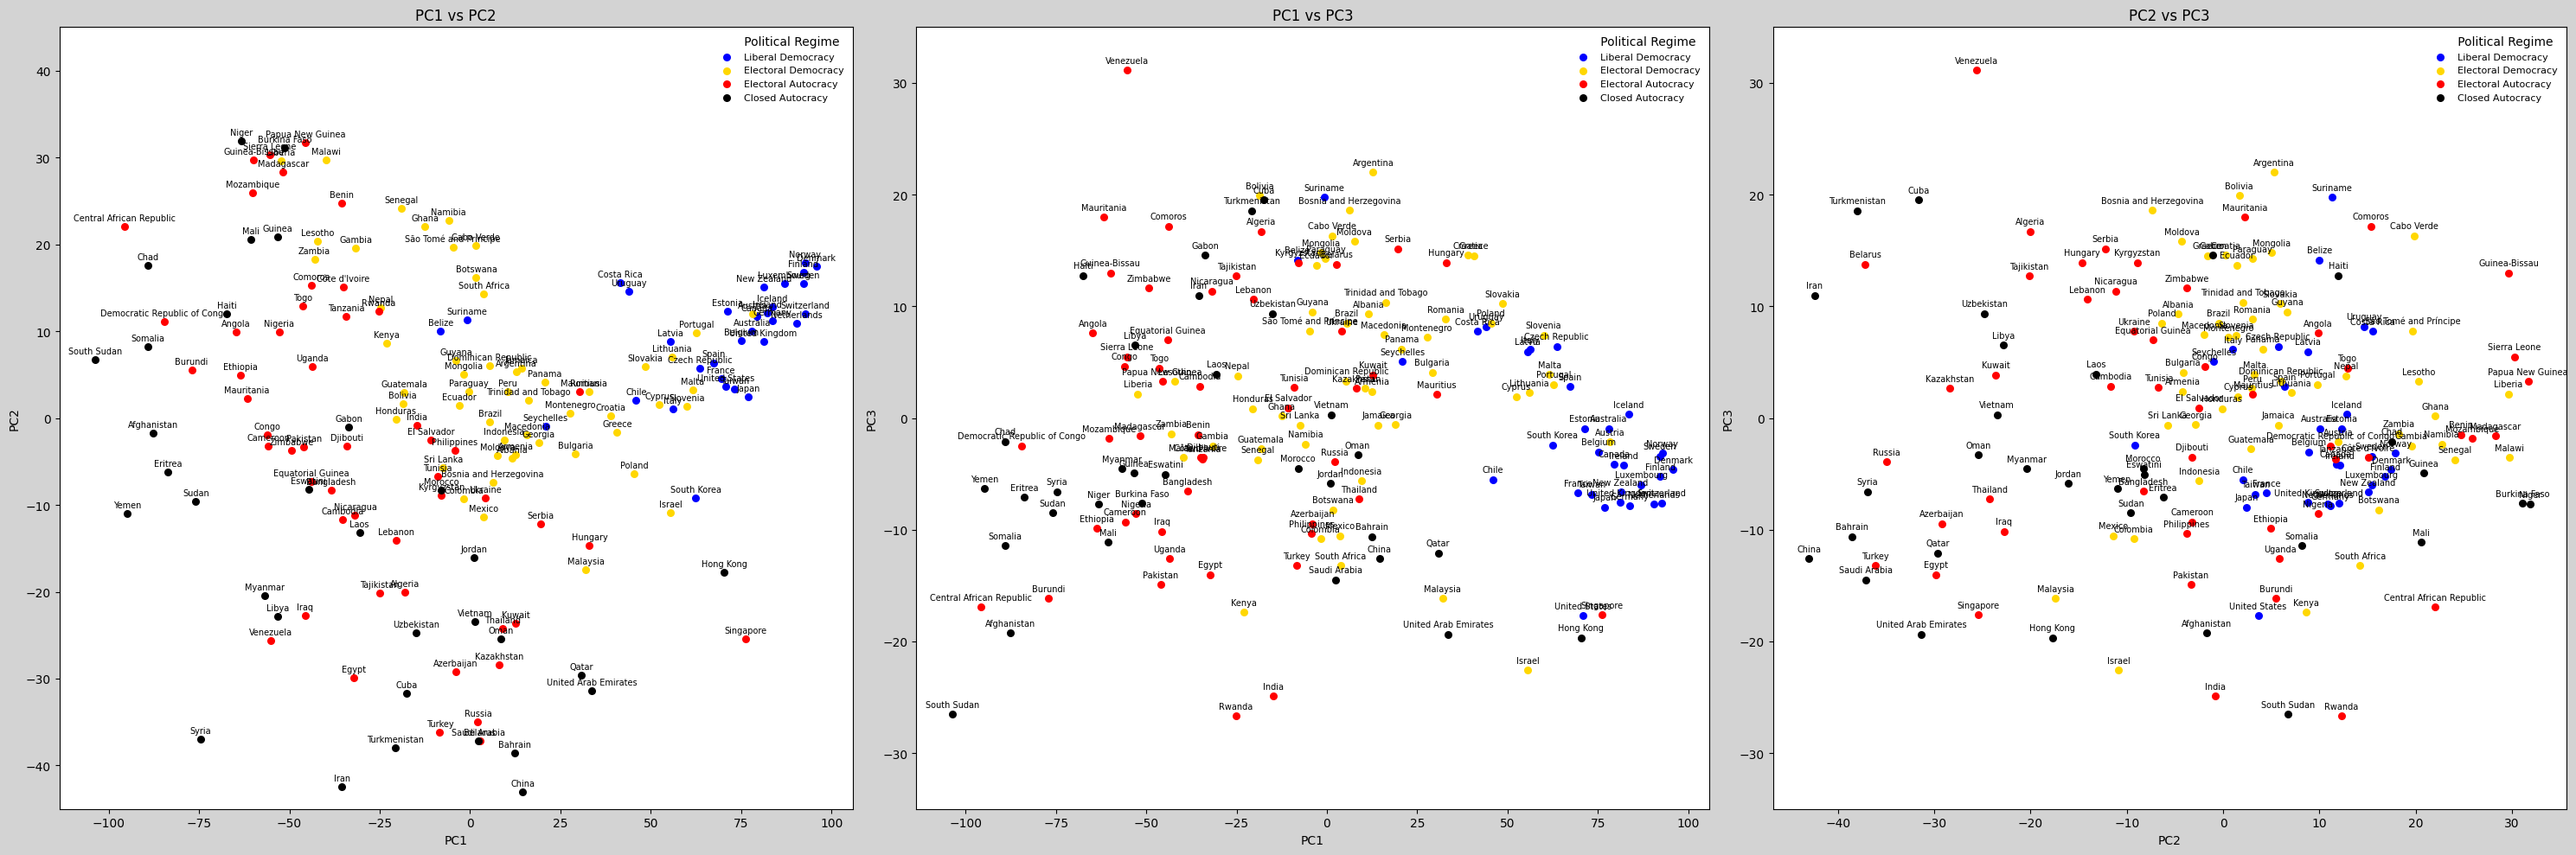

In [134]:
pc_scores = pd.DataFrame(data = pca_fit[:, :3], columns=["PC1", "PC2", "PC3"])
display(pc_scores)
pc_scores["Country"] = prosperity_scores["country"]
pc_scores["Region"] = prosperity_scores["region"]
pc_scores["Political Regime"] = prosperity_scores["political_regime"]

regime_colors = {
    "Liberal Democracy": (0/255, 0/255, 255/255),       # blue
    "Electoral Democracy": (255/255, 215/255, 0/255),   # yellow
    "Electoral Autocracy": (255/255, 0/255, 0/255),     # red
    "Closed Autocracy": (0/255, 0/255, 0/255)           # black
}

fig, axes = plt.subplots(1, 3, figsize = (30, 10), facecolor = "lightgray")
def plot_scatter(ax, x_col, y_col, xlabel, ylabel, title):
    
    for regime in regime_colors.keys():
        subset = pc_scores[pc_scores["Political Regime"] == regime]
        ax.scatter(subset[x_col], subset[y_col], alpha = 1, s = 30, 
                   label = regime, color = regime_colors[regime])
    for i, txt in enumerate(pc_scores["Country"]):
        ax.text(pc_scores[x_col][i], pc_scores[y_col][i] + 0.5, txt, 
                fontsize = 7, ha = "center", va = "bottom")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    legend = ax.legend(title = "      Political Regime", fontsize = 8, 
                       loc = "upper right", frameon = False)
    legend.get_frame().set_facecolor("lightgray")
    

# Plot PC1 vs PC2

plot_scatter(axes[0], "PC1", "PC2", "PC1", "PC2", "PC1 vs PC2")
axes[0].set_ylim(-45, 45)

# Plot PC1 vs PC3

plot_scatter(axes[1], "PC1", "PC3", "PC1", "PC3", "PC1 vs PC3")
axes[1].set_ylim(-35, 35)

# Plot PC2 vs PC3

plot_scatter(axes[2], "PC2", "PC3", "PC2", "PC3", "PC2 vs PC3")
axes[2].set_ylim(-35, 35)

plt.tight_layout()
plt.show()

### Interactive 3-D Plot of PC Scores

In [146]:
import plotly.io as pio
from IPython.display import IFrame, display, HTML

fig = px.scatter_3d(
    pc_scores, 
    x = "PC1", 
    y = "PC2", 
    z = "PC3", 
    text = "Country", 
    color = "Region",  
    opacity = 1,
    title = "Interactive 3D PCA Scatter Plot"
)

fig.update_traces(marker = dict(size = 4))
fig.update_layout(
    height = 1000, width = 1000,
    scene = dict(
        xaxis_title = "PC1",
        yaxis_title = "PC2",
        zaxis_title = "PC3"
    ),
    legend = dict(
        title = dict(text = "       Region", side = "top")
    )
)

fig.show()

html_filename = "pca_3d_plot_embedded.html"
pio.write_html(fig, file = html_filename, full_html = True, include_plotlyjs = "cdn")

display(HTML(f"""
    <div style="display: flex; justify-content: center;">
        <iframe src="{html_filename}" width="1100" height="1100"></iframe>
    </div>
"""))
